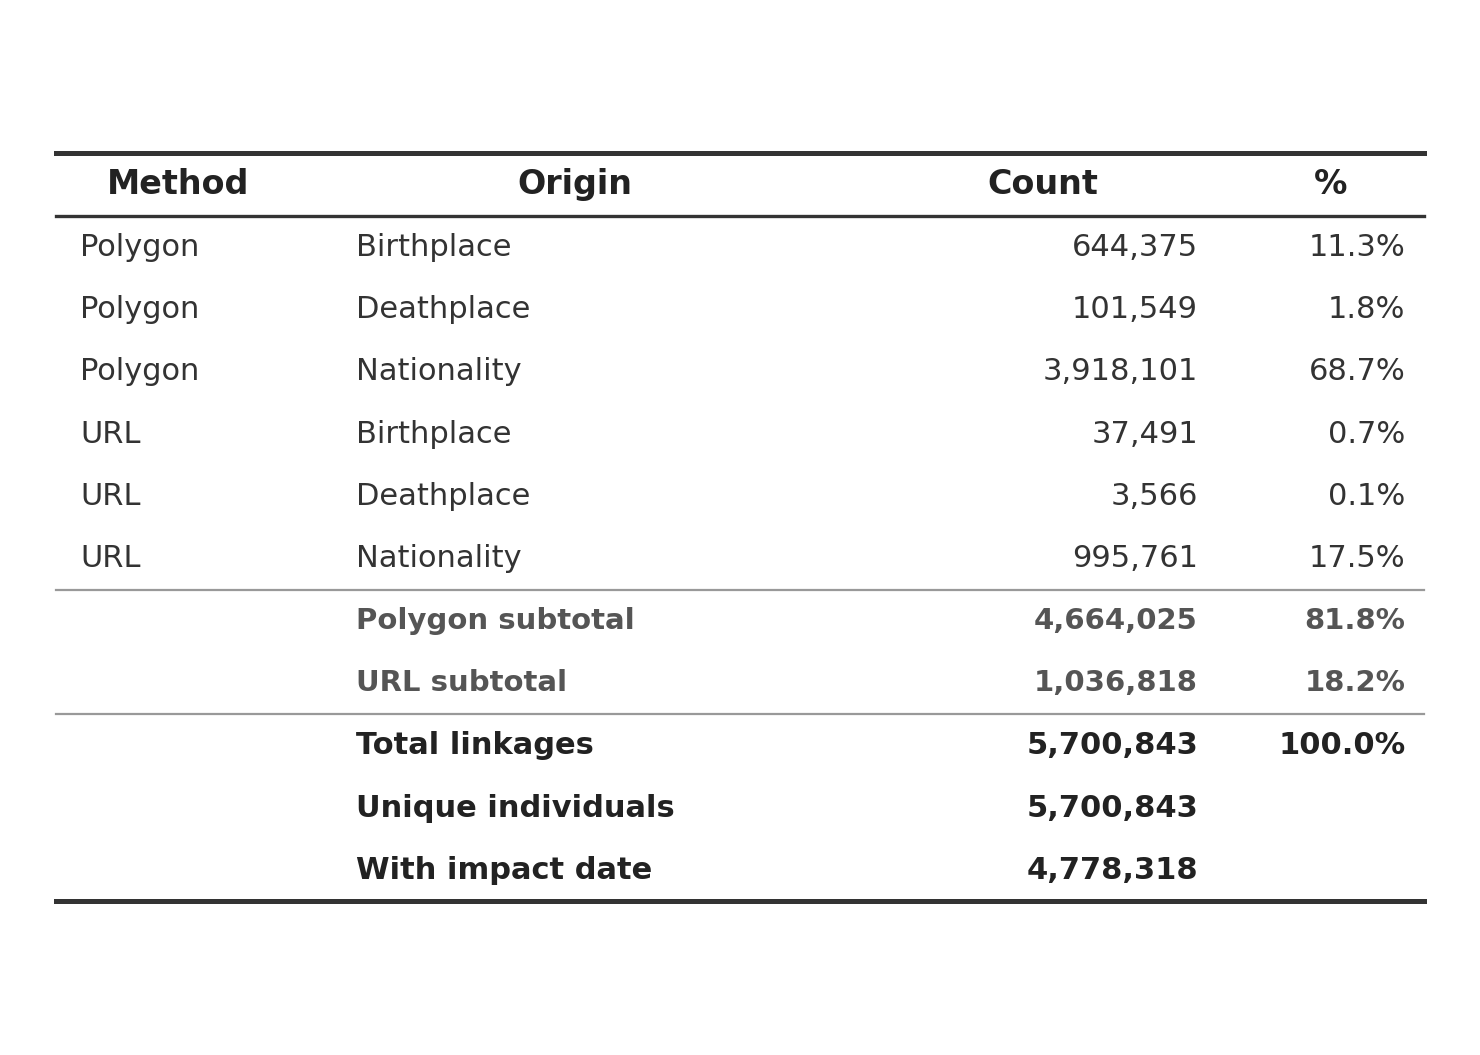

Saved to tables/table_linkage_statistics.png


In [1]:
import sqlite3
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'

DB = '../data/humans_clean.sqlite3'

conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

# ── Count linkages by method and origin (merge url + url_fallback) ──
cur = conn.execute('''
    SELECT
        CASE WHEN method IN ('url', 'url_fallback') THEN 'url' ELSE method END AS method_group,
        origin,
        COUNT(*) AS n
    FROM individuals_cliopatria
    GROUP BY method_group, origin
    ORDER BY method_group, origin
''')

detail_rows = []
for method, origin, n in cur:
    detail_rows.append((method, origin, n))

polygon_total = sum(n for m, _, n in detail_rows if m == 'polygon')
url_total     = sum(n for m, _, n in detail_rows if m == 'url')
grand_total   = sum(n for _, _, n in detail_rows)

distinct_all = conn.execute(
    'SELECT COUNT(DISTINCT wikidata_id) FROM individuals_cliopatria'
).fetchone()[0]

distinct_impact = conn.execute(
    'SELECT COUNT(DISTINCT wikidata_id) FROM individuals_cliopatria WHERE impact_date IS NOT NULL'
).fetchone()[0]

conn.close()

# ── Build cell data ──
METHOD = {'polygon': 'Polygon', 'url': 'URL'}
ORIGIN = {'nationality': 'Nationality', 'birthplace': 'Birthplace', 'deathplace': 'Deathplace'}

cell_text = []
for method, origin, count in detail_rows:
    cell_text.append([
        METHOD.get(method, method),
        ORIGIN.get(origin, origin),
        f'{count:,}',
        f'{count / grand_total * 100:.1f}%',
    ])

summary_rows = [
    ['', 'Polygon subtotal',   f'{polygon_total:,}',  f'{polygon_total/grand_total*100:.1f}%'],
    ['', 'URL subtotal',       f'{url_total:,}',      f'{url_total/grand_total*100:.1f}%'],
    ['', 'Total linkages',     f'{grand_total:,}',     '100.0%'],
    ['', 'Unique individuals', f'{distinct_all:,}',    ''],
    ['', 'With impact date',   f'{distinct_impact:,}', ''],
]

all_rows = cell_text + summary_rows
n_detail = len(cell_text)
n_all = len(all_rows)
col_labels = ['Method', 'Origin', 'Count', '%']

# ── Render ──
fig_height = 0.42 * (n_all + 1) + 0.6
fig, ax = plt.subplots(figsize=(7.5, fig_height), dpi=200)
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

table = ax.table(
    cellText=all_rows,
    colLabels=col_labels,
    cellLoc='center',
    colLoc='center',
    loc='center',
    edges='open',
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.6)

# ── Style header ──
for j in range(len(col_labels)):
    cell = table[0, j]
    cell.set_text_props(fontweight='bold', color='#222222', fontsize=12)
    cell.set_facecolor('white')
    cell.set_edgecolor('white')
    cell.get_text().set_ha('center')

# ── Style detail rows ──
for i in range(1, n_detail + 1):
    for j in range(len(col_labels)):
        cell = table[i, j]
        cell.set_facecolor('#fafafa' if i % 2 == 0 else 'white')
        cell.set_edgecolor('white')
        cell.set_text_props(fontsize=11, color='#333333')
        if j <= 1:
            cell.get_text().set_ha('left')
        else:
            cell.get_text().set_ha('right')

# ── Style summary rows ──
for i in range(n_detail + 1, n_all + 1):
    row_idx = i - n_detail - 1
    for j in range(len(col_labels)):
        cell = table[i, j]
        cell.set_edgecolor('white')
        if j <= 1:
            cell.get_text().set_ha('left')
        else:
            cell.get_text().set_ha('right')
        if row_idx <= 1:  # subtotals
            cell.set_facecolor('#f0f0f0')
            cell.set_text_props(fontweight='bold', fontsize=10.5, color='#555555')
        else:  # total linkages, unique individuals, with impact date
            cell.set_facecolor('#e4e4e4')
            cell.set_text_props(fontweight='bold', fontsize=11, color='#222222')

# ── Column widths ──
col_widths = [0.17, 0.38, 0.27, 0.13]
for i in range(n_all + 1):
    for j, w in enumerate(col_widths):
        table[i, j].set_width(w)

# ── Draw horizontal rules ──
# Get table bounding box
renderer = fig.canvas.get_renderer()
tbb = table.get_window_extent(renderer)
tbb_ax = tbb.transformed(ax.transData.inverted())

x_left = tbb_ax.x0
x_right = tbb_ax.x1
row_height = (tbb_ax.y1 - tbb_ax.y0) / (n_all + 1)

# Line above header
y_top = tbb_ax.y1
ax.plot([x_left, x_right], [y_top, y_top], color='#333333', linewidth=1.8,
        clip_on=False, transform=ax.transData)

# Line below header
y_below_header = tbb_ax.y1 - row_height
ax.plot([x_left, x_right], [y_below_header, y_below_header], color='#333333',
        linewidth=1.2, clip_on=False, transform=ax.transData)

# Line above subtotals (between detail and summary)
y_above_summary = tbb_ax.y1 - (n_detail + 1) * row_height
ax.plot([x_left, x_right], [y_above_summary, y_above_summary], color='#999999',
        linewidth=0.8, clip_on=False, transform=ax.transData)

# Line above totals (between subtotals and totals)
y_above_totals = tbb_ax.y1 - (n_detail + 3) * row_height
ax.plot([x_left, x_right], [y_above_totals, y_above_totals], color='#999999',
        linewidth=0.8, clip_on=False, transform=ax.transData)

# Line at bottom
y_bottom = tbb_ax.y0
ax.plot([x_left, x_right], [y_bottom, y_bottom], color='#333333', linewidth=1.8,
        clip_on=False, transform=ax.transData)

plt.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.05)
plt.savefig('tables/table_linkage_statistics.png', dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none', pad_inches=0.15)
plt.show()
print('Saved to tables/table_linkage_statistics.png')